### **1. Introduction**
The features are now agronomically sound but they exist on vastly different scales (ex: Sand % ranges from 0-100, while pH ranges from 4-9). Most clustering algorithms, such as K-Means, use Euclidean distance to group data points. If these features are not scaled, the algorithm will be biased toward the variable with the largest numerical range.

* Outlier Management: Identify and cap extreme values that could skew cluster centroids.
* Feature Standardization: Transform all features to a common scale (Mean = 0, Std = 1).
* Model Serialization: Save the scaler object for future use in crop recommendations.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv("../outputs/soil_features_final.csv")

CLUSTER_FEATURES = [
    "taw",
    "organic_carbon",
    "cec",
    "ph",
    "sand_pct"
]

### **2. Outlier Detection**
Outliers can significantly distort the cente of a cluster. Boxplots were used to visualize the distribution of the features and identify points that lie far outside the Interquartile Range (IQR).

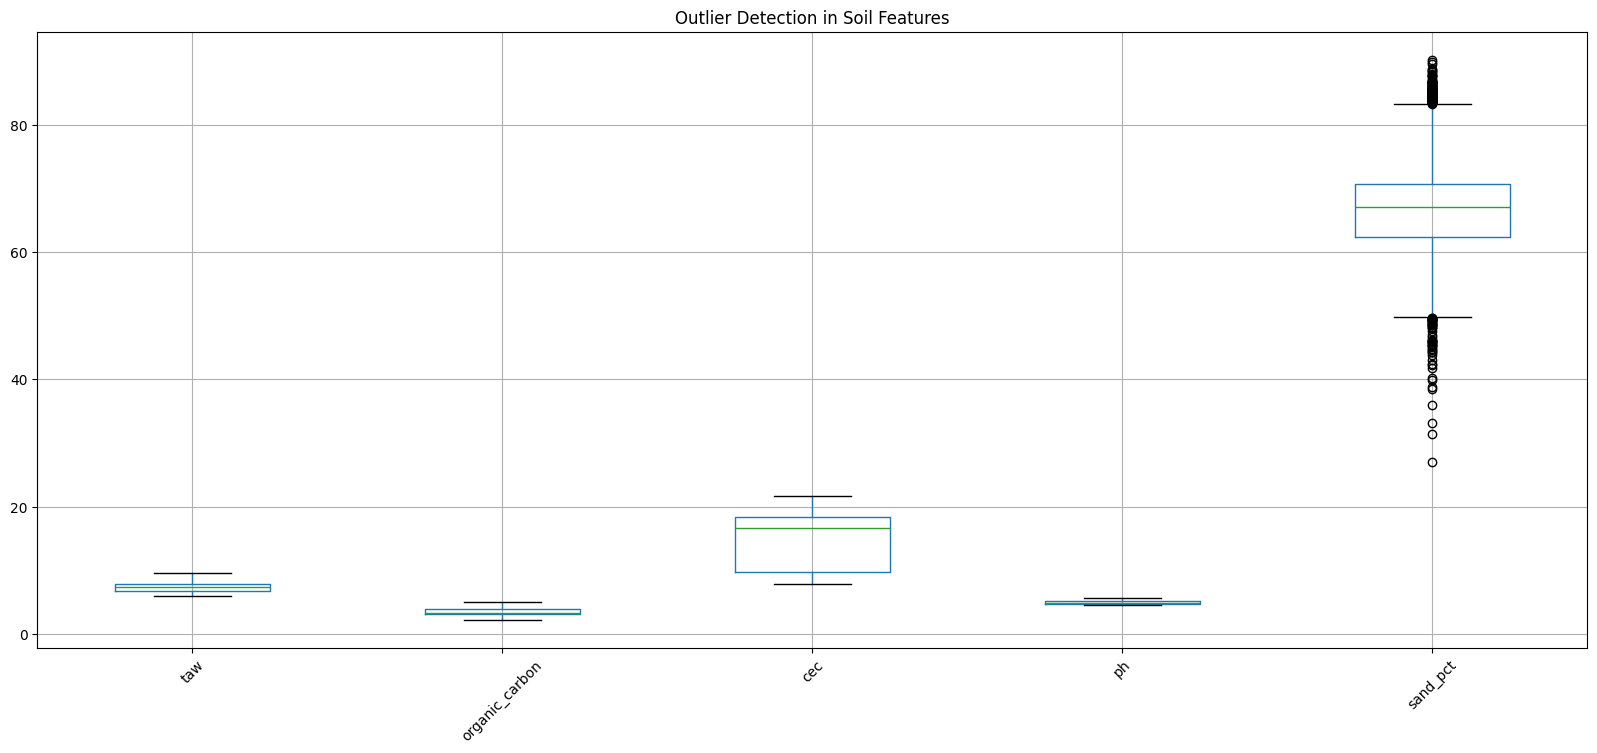

In [14]:
plt.figure(figsize=(20, 8))
df[CLUSTER_FEATURES].boxplot()
plt.title("Outlier Detection in Soil Features")
plt.xticks(rotation=45)
plt.show()

### **3. Handling Extreme Values**
Based on the visual analysis, Sand % contains extreme values at the edges of the distribution that may represent rare soil anomalies or sensor noise. Instead of deleting these pixels, capping (winsorization) was used at the 1st and 99th percentiles.

This preserves the spatial integrity of the map while preventing extreme values from pulling the cluster centers away from the majority of the data.

Outliers capped at 1st and 99th percentiles.


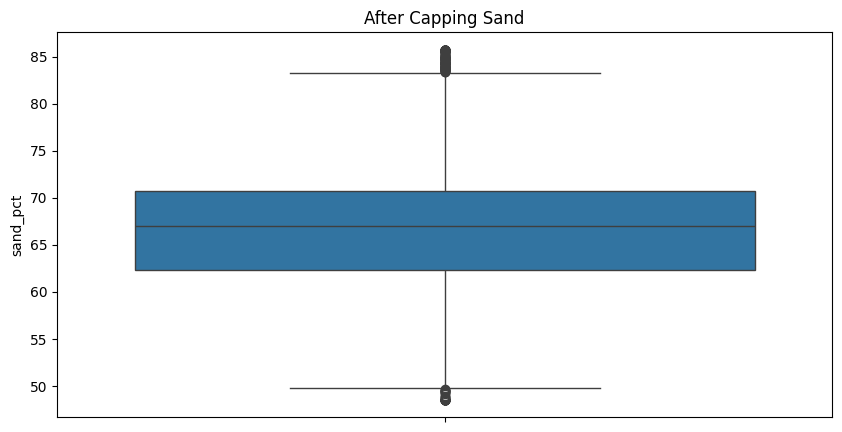

In [15]:
for feature in ['sand_pct']:
    lower_limit = df[feature].quantile(0.01)
    upper_limit = df[feature].quantile(0.99)
  
    df[feature] = df[feature].clip(lower_limit, upper_limit)

print("Outliers capped at 1st and 99th percentiles.")

plt.figure(figsize=(10, 5))
sns.boxplot(data=df['sand_pct'])
plt.title("After Capping Sand")
plt.show()

### **4. Final Multicollinearity Check**
With Clay and Bulk Density removed, a final correlation check was performed expecting to see moderate relationships but no near perfect correlations that would destabilize the model.

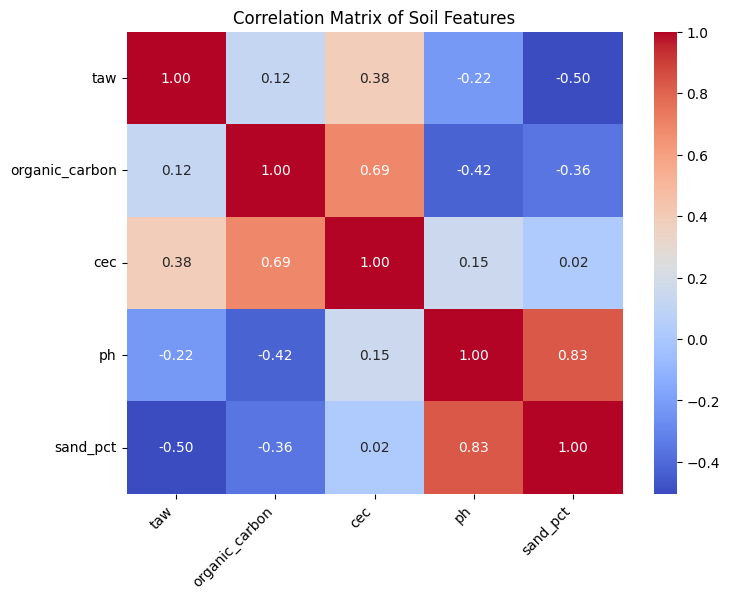

In [16]:
plt.figure(figsize=(8, 6))
corr_matrix = df[CLUSTER_FEATURES].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Soil Features")
plt.show()

### **5. Feature Standardization (Z-Score Scaling)**
The StandardScaler was applied to the features. This calculates the $z$-score for every pixel, ensuring every feature contributes equally to the clustering process.
$$z = \frac{x - \mu}{\sigma}$$
$z$: The standardized value\
$x$: The original feature value\
$\mu$: The mean of the feature\
$\sigma$: The standard deviation

In [17]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[CLUSTER_FEATURES])

df_scaled = pd.DataFrame(scaled_data, columns=CLUSTER_FEATURES)

df_scaled[['lat', 'lon', 'texture_class']] = df[['lat', 'lon', 'texture_class']]

print("Scaling complete. All features now have a mean of 0 and a standard deviation of 1.")

Scaling complete. All features now have a mean of 0 and a standard deviation of 1.


### **6. Validation of Scaled Distributions**
After scaling, verification was done to verify that:

* The Mean for every feature is approximately 0.
* The Standard Deviation for every feature is exactly 1.
* The relative distribution of the data remains unchanged.

      taw  organic_carbon  cec   ph  sand_pct
mean  0.0             0.0  0.0 -0.0      -0.0
std   1.0             1.0  1.0  1.0       1.0


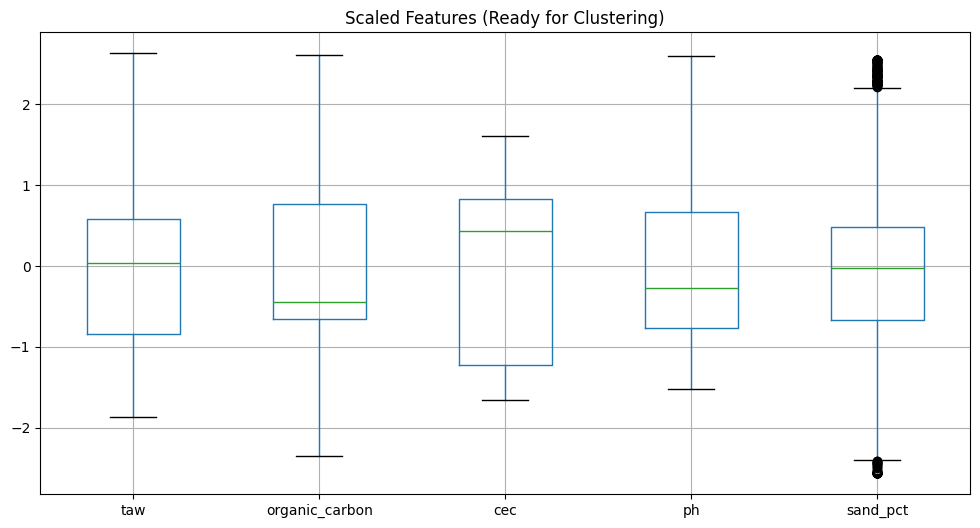

In [18]:
print(df_scaled[CLUSTER_FEATURES].describe().round(2).loc[['mean', 'std']])

plt.figure(figsize=(12, 6))
df_scaled[CLUSTER_FEATURES].boxplot()
plt.title("Scaled Features (Ready for Clustering)")
plt.show()

### **7. Saving Preprocessed Data & Scaler**
The scaled dataset was exported for the clustering stage, also saved the scaler.pkl file.

In [19]:
output_path_1 = "../outputs/soil_features_scaled.csv"
output_path_2 = "../outputs/soil_scaler.pkl"
df_scaled.to_csv(output_path_1, index=False)
joblib.dump(scaler, output_path_2)

print("Saved:", output_path_1)
print("Saved:", output_path_2)

Saved: ../outputs/soil_features_scaled.csv
Saved: ../outputs/soil_scaler.pkl
